# Exp0.1.4 — Parallel Regularization Repair Ablation

Analysis-only notebook for the 30-epoch paired regularization repair sweep. The equal-budget control is `no_reg`; frozen Exp0.1 100-epoch results are historical context only.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "AGENTS.md").exists() and (candidate / "scripts").exists():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root")


REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / "notebooks" / "artifacts" / "experiment_0_1_4_parallel_regularization_ablation" / "parallel_regularization_ablation_v1"

manifest = json.loads((ROOT / "manifest.json").read_text(encoding="utf-8"))
runs = pd.read_csv(ROOT / "runs.csv")
summary = pd.read_csv(ROOT / "summary.csv")
history = pd.read_csv(ROOT / "history_long.csv")
paired = pd.read_csv(ROOT / "paired_condition_effects.csv")
paired_summary = pd.read_csv(ROOT / "paired_condition_summary.csv")
gradient_summary = pd.read_csv(ROOT / "gradient_diagnostics_summary.csv")
frozen = pd.read_csv(ROOT / "frozen_exp01_summary.csv")
comparison = pd.read_csv(ROOT / "comparison_summary.csv")

print(json.dumps(manifest["run_matrix"], indent=2))
print(f"runs={len(runs)} history_rows={len(history)} paired_rows={len(paired)}")


{
  "architectures": [
    "short_mid_long",
    "short_mid",
    "mid_long"
  ],
  "conditions": [
    "no_reg",
    "original_reg",
    "temporal_norm",
    "tau_gain_norm",
    "warmup",
    "all_fixes"
  ],
  "hidden_cap": 1,
  "objectives": [
    "whole_count_ce",
    "timestep_ce"
  ],
  "seeds": [
    11,
    23,
    37,
    53,
    71
  ],
  "total_runs": 180,
  "variant": "binary"
}
runs=180 history_rows=5400 paired_rows=150


## Five-seed test BA by condition

The main table compares all six 30-epoch conditions on identical architecture/objective/seed pairs.


In [2]:
ba_table = summary.pivot_table(
    index=["architecture", "objective"],
    columns="condition",
    values="test_ba_mean",
)
condition_order = manifest["run_matrix"]["conditions"]
ba_table = ba_table.reindex(columns=[c for c in condition_order if c in ba_table.columns])
display(ba_table.round(4))


condition                      no_reg  original_reg  temporal_norm  \
architecture   objective                                             
mid_long       timestep_ce     0.1924        0.0839         0.1519   
               whole_count_ce  0.3414        0.0898         0.2418   
short_mid      timestep_ce     0.1322        0.0833         0.0850   
               whole_count_ce  0.2266        0.0833         0.1295   
short_mid_long timestep_ce     0.1062        0.0842         0.0812   
               whole_count_ce  0.1195        0.0842         0.0853   

condition                      tau_gain_norm  warmup  all_fixes  
architecture   objective                                         
mid_long       timestep_ce            0.0971  0.0772     0.1699  
               whole_count_ce         0.1872  0.0768     0.3093  
short_mid      timestep_ce            0.0833  0.0833     0.1058  
               whole_count_ce         0.0833  0.0833     0.1866  
short_mid_long timestep_ce            0.0854  0.0842     0.0920  
               whole_count_ce         0.0857  0.0842     0.1125

## Paired delta relative to 30-epoch no-reg control

Positive `delta_test_ba_vs_no_reg` means the regularization condition improved over the equal-budget baseline.


In [3]:
delta_table = paired_summary.pivot_table(
    index=["architecture", "objective"],
    columns="condition",
    values="delta_test_ba_vs_no_reg_mean",
)
display(delta_table.round(4))

best = (
    paired_summary.sort_values("delta_test_ba_vs_no_reg_mean", ascending=False)
    [["condition", "architecture", "objective", "delta_test_ba_vs_no_reg_mean", "delta_test_ba_vs_no_reg_std"]]
)
display(best.head(18).round(4))


condition                      all_fixes  original_reg  tau_gain_norm  \
architecture   objective                                                
mid_long       timestep_ce       -0.0225       -0.1085        -0.0953   
               whole_count_ce    -0.0321       -0.2515        -0.1541   
short_mid      timestep_ce       -0.0265       -0.0489        -0.0489   
               whole_count_ce    -0.0400       -0.1432        -0.1432   
short_mid_long timestep_ce       -0.0141       -0.0220        -0.0208   
               whole_count_ce    -0.0070       -0.0353        -0.0337   

condition                      temporal_norm  warmup  
architecture   objective                              
mid_long       timestep_ce           -0.0406 -0.1153  
               whole_count_ce        -0.0995 -0.2646  
short_mid      timestep_ce           -0.0472 -0.0489  
               whole_count_ce        -0.0970 -0.1432  
short_mid_long timestep_ce           -0.0250 -0.0220  
               whole_count_ce        -0.0342 -0.0353

,condition,architecture,objective,delta_test_ba_vs_no_reg_mean,delta_test_ba_vs_no_reg_std
5,all_fixes,short_mid_long,whole_count_ce,-0.0070,0.0238
4,all_fixes,short_mid_long,timestep_ce,-0.0141,0.0270
16,tau_gain_norm,short_mid_long,timestep_ce,-0.0208,0.0336
10,original_reg,short_mid_long,timestep_ce,-0.0220,0.0324
28,warmup,short_mid_long,timestep_ce,-0.0220,0.0324
0,all_fixes,mid_long,timestep_ce,-0.0225,0.0214
22,temporal_norm,short_mid_long,timestep_ce,-0.0250,0.0425
2,all_fixes,short_mid,timestep_ce,-0.0265,0.0416
1,all_fixes,mid_long,whole_count_ce,-0.0321,0.0340
17,tau_gain_norm,short_mid_long,whole_count_ce,-0.0337,0.0149


## Firing preservation and dead-neuron behavior

These paired metrics test whether a condition improves BA by preserving useful firing rather than simply reducing membrane magnitude.


In [4]:
firing_cols = [
    "condition",
    "architecture",
    "objective",
    "delta_last_hidden_events_per_neuron_second_vs_no_reg_mean",
    "delta_last_hidden_dead_neuron_fraction_vs_no_reg_mean",
    "delta_test_ba_vs_no_reg_mean",
]
display(
    paired_summary[firing_cols]
    .sort_values(["architecture", "objective", "condition"])
    .round(4)
)


,condition,architecture,objective,delta_last_hidden_events_per_neuron_second_vs_no_reg_mean,delta_last_hidden_dead_neuron_fraction_vs_no_reg_mean,delta_test_ba_vs_no_reg_mean
0,all_fixes,mid_long,timestep_ce,-3.6125,-0.0016,-0.0225
6,original_reg,mid_long,timestep_ce,-5.5888,0.0516,-0.1085
12,tau_gain_norm,mid_long,timestep_ce,-5.8949,0.1188,-0.0953
18,temporal_norm,mid_long,timestep_ce,-6.2742,0.0000,-0.0406
24,warmup,mid_long,timestep_ce,-5.5606,0.0203,-0.1153
1,all_fixes,mid_long,whole_count_ce,-1.8827,-0.0125,-0.0321
7,original_reg,mid_long,whole_count_ce,-7.9508,0.0312,-0.2515
13,tau_gain_norm,mid_long,whole_count_ce,-7.6605,0.0812,-0.1541
19,temporal_norm,mid_long,whole_count_ce,-5.6163,-0.0219,-0.0995
25,warmup,mid_long,whole_count_ce,-8.0375,0.0406,-0.2646


## 30-epoch no-reg versus frozen 100-epoch Exp0.1 context

This is not a paired equal-budget comparison. It only indicates how much performance may still be left from extending training beyond 30 epochs.


In [5]:
no_reg = summary[summary["condition"] == "no_reg"][
    ["architecture", "objective", "test_ba_mean", "test_ba_std"]
].rename(columns={"test_ba_mean":"no_reg_30ep_mean", "test_ba_std":"no_reg_30ep_std"})
context = frozen.rename(columns={"mean":"exp01_100ep_mean", "std":"exp01_100ep_std"})
context_compare = no_reg.merge(context, on=["architecture", "objective"], how="left")
context_compare["delta_100ep_minus_30ep"] = context_compare["exp01_100ep_mean"] - context_compare["no_reg_30ep_mean"]
display(context_compare.round(4))


,architecture,objective,no_reg_30ep_mean,no_reg_30ep_std,exp01_100ep_mean,exp01_100ep_std,count,system,delta_100ep_minus_30ep
0,mid_long,timestep_ce,0.1924,0.0209,0.3040,0.0450,5,frozen_exp0.1_100epoch,0.1116
1,mid_long,whole_count_ce,0.3414,0.0591,0.4008,0.0306,5,frozen_exp0.1_100epoch,0.0594
2,short_mid,timestep_ce,0.1322,0.0342,0.2815,0.0252,5,frozen_exp0.1_100epoch,0.1492
3,short_mid,whole_count_ce,0.2266,0.0385,0.4572,0.0270,5,frozen_exp0.1_100epoch,0.2306
4,short_mid_long,timestep_ce,0.1062,0.0343,0.1321,0.0157,5,frozen_exp0.1_100epoch,0.0259
5,short_mid_long,whole_count_ce,0.1195,0.0162,0.2187,0.0157,5,frozen_exp0.1_100epoch,0.0993


## Gradient competition diagnostics

Gradient ratios are measured on the first training batch only at epochs 1, 2, 5, 10, 20, and 30.


In [6]:
grad_cols = [
    "condition",
    "architecture",
    "objective",
    "epoch",
    "first_batch_p2_to_task_grad_ratio_mean",
    "first_batch_a1_to_task_grad_ratio_mean",
    "first_batch_reg_to_task_grad_ratio_mean",
    "train_reg_to_task_ratio_mean",
    "val_native_ba_mean",
]
display(
    gradient_summary[grad_cols]
    .sort_values(["architecture", "objective", "condition", "epoch"])
    .round(4)
)


,condition,architecture,objective,epoch,first_batch_p2_to_task_grad_ratio_mean,first_batch_a1_to_task_grad_ratio_mean,first_batch_reg_to_task_grad_ratio_mean,train_reg_to_task_ratio_mean,val_native_ba_mean
0,all_fixes,mid_long,timestep_ce,1,0.0000,0.0003,0.0003,0.0002,0.0770
1,all_fixes,mid_long,timestep_ce,2,0.0001,0.0092,0.0092,0.0005,0.0844
2,all_fixes,mid_long,timestep_ce,5,0.0020,0.1167,0.1173,0.0012,0.0872
3,all_fixes,mid_long,timestep_ce,10,0.0009,0.0502,0.0504,0.0018,0.1027
4,all_fixes,mid_long,timestep_ce,20,0.0002,0.0201,0.0201,0.0014,0.1468
...,...,...,...,...,...,...,...,...,...
211,warmup,short_mid_long,whole_count_ce,2,28.2560,0.0008,28.2562,0.1113,0.0847
212,warmup,short_mid_long,whole_count_ce,5,66.9876,0.0108,66.9937,0.0373,0.0833
213,warmup,short_mid_long,whole_count_ce,10,331.8725,0.0939,331.9386,0.0227,0.0833
214,warmup,short_mid_long,whole_count_ce,20,4775.2333,3.6171,4776.6488,0.0046,0.0833


## Validation BA trajectories

Each line is the five-seed mean for one condition. One figure is generated per architecture/objective pair.


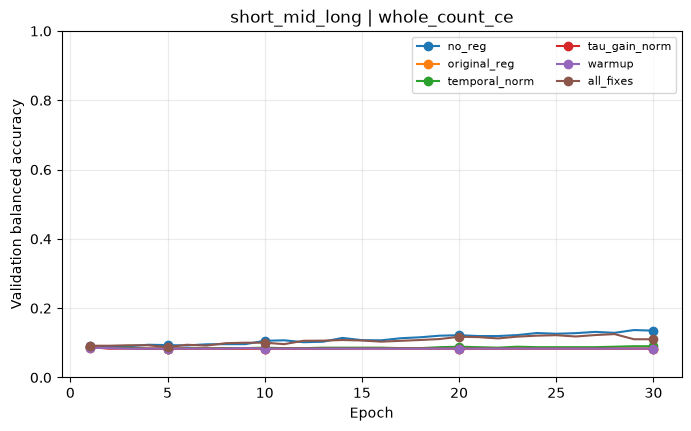

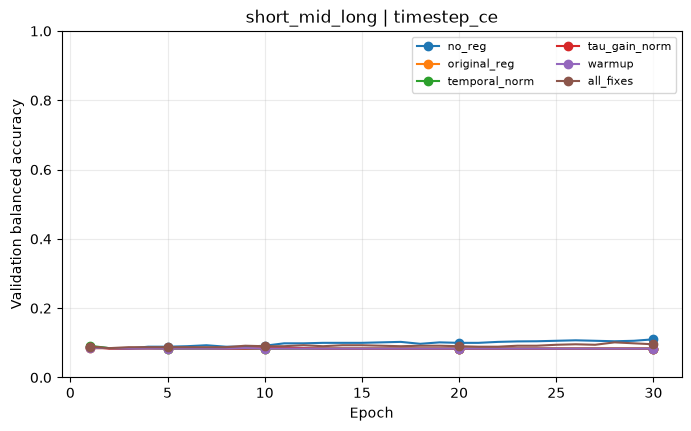

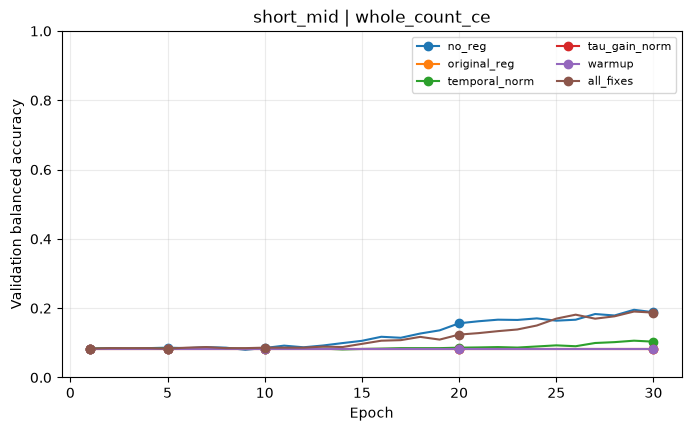

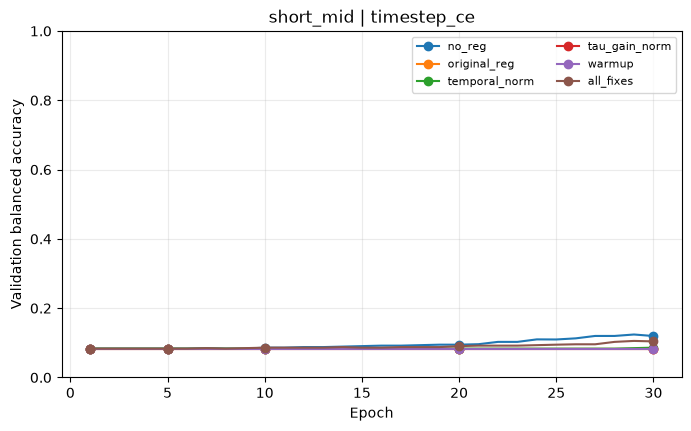

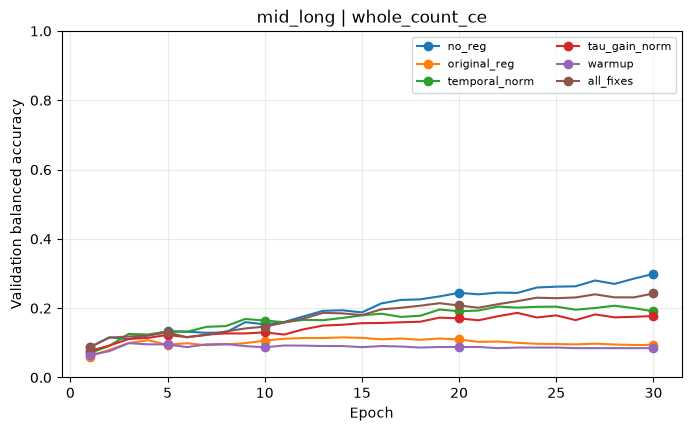

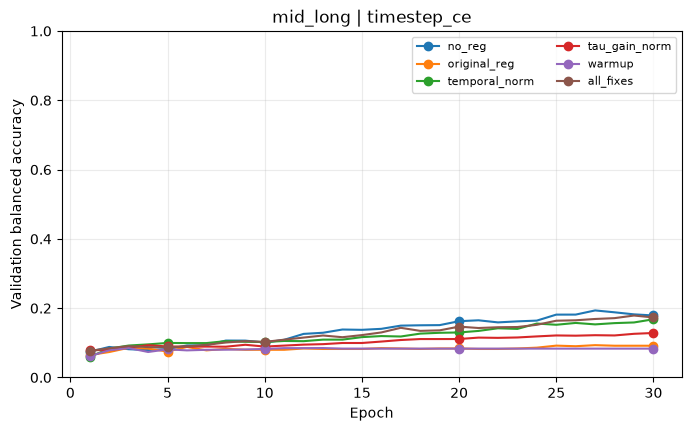

In [7]:
curve = (
    history.groupby(["condition", "architecture", "objective", "epoch"], as_index=False)["val_native_ba"]
    .agg(["mean", "std"])
    .reset_index()
)

for architecture in manifest["run_matrix"]["architectures"]:
    for objective in manifest["run_matrix"]["objectives"]:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        subset = curve[(curve["architecture"] == architecture) & (curve["objective"] == objective)]
        for condition in condition_order:
            part = subset[subset["condition"] == condition]
            if part.empty:
                continue
            ax.plot(part["epoch"], part["mean"], marker="o", markevery=[0, 4, 9, 19, 29], label=condition)
        ax.set_title(f"{architecture} | {objective}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation balanced accuracy")
        ax.set_ylim(0.0, 1.0)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, ncol=2)
        plt.show()


## Gradient-ratio trajectories at diagnostic epochs

A ratio above 1 means the combined weighted regularizer gradient is larger than the task gradient on that diagnostic batch.


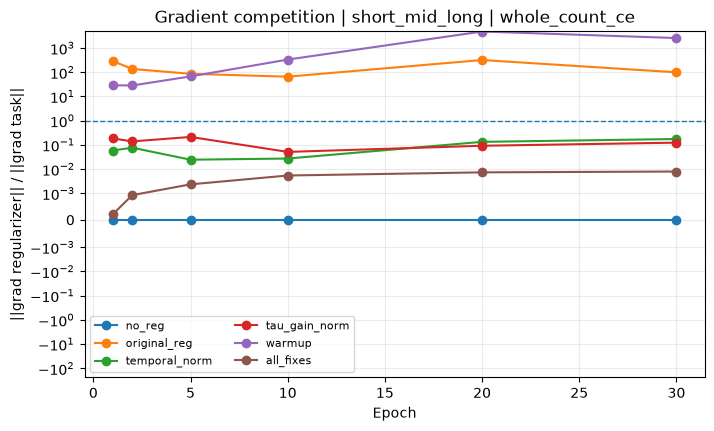

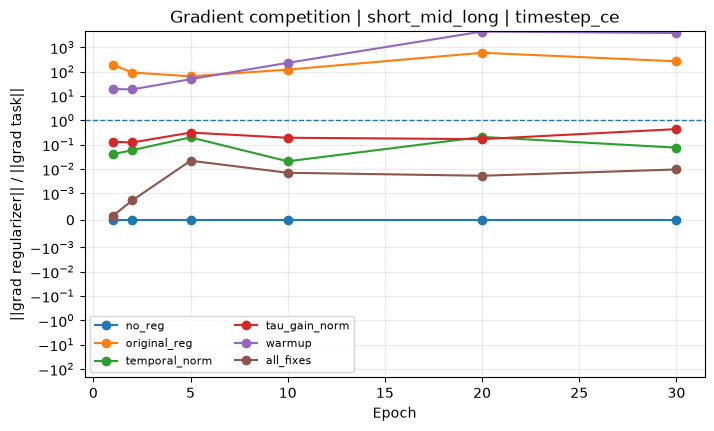

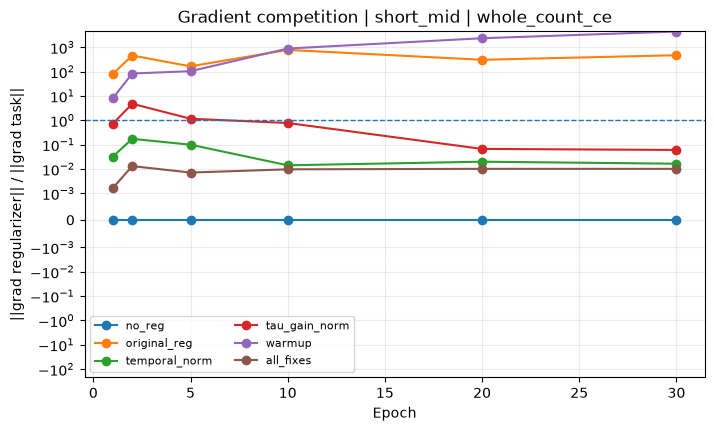

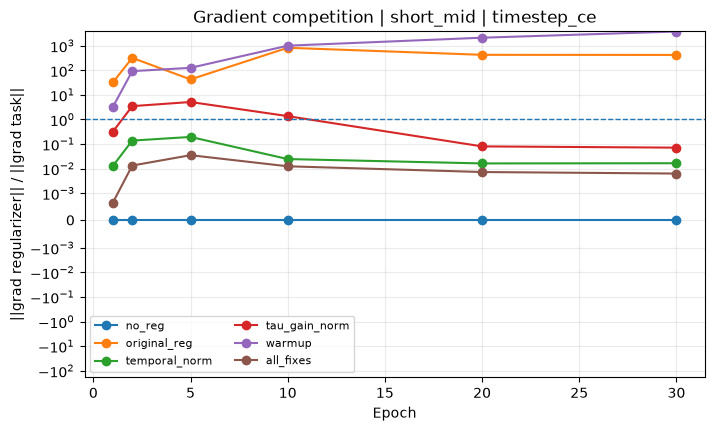

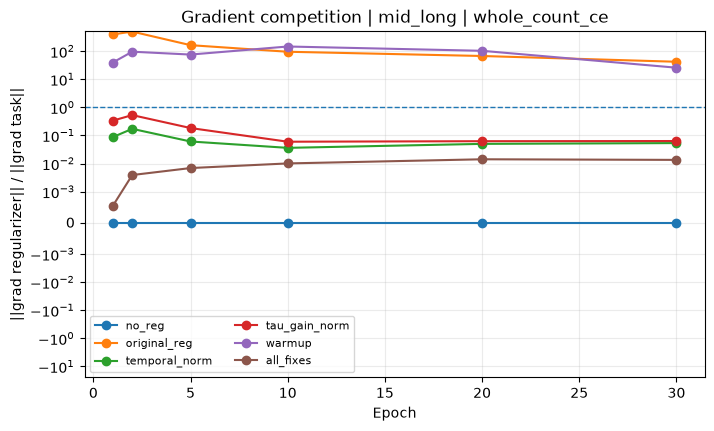

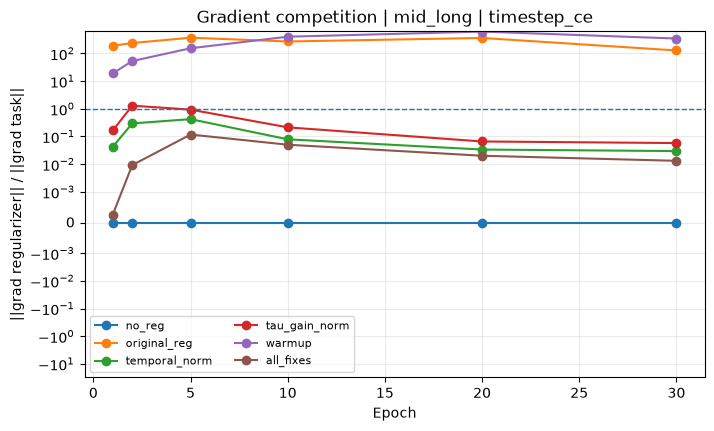

In [8]:
grad_curve = gradient_summary.copy()
for architecture in manifest["run_matrix"]["architectures"]:
    for objective in manifest["run_matrix"]["objectives"]:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        subset = grad_curve[(grad_curve["architecture"] == architecture) & (grad_curve["objective"] == objective)]
        for condition in condition_order:
            part = subset[subset["condition"] == condition]
            if part.empty:
                continue
            ax.plot(
                part["epoch"],
                part["first_batch_reg_to_task_grad_ratio_mean"],
                marker="o",
                label=condition,
            )
        ax.axhline(1.0, linestyle="--", linewidth=1)
        ax.set_yscale("symlog", linthresh=1e-3)
        ax.set_title(f"Gradient competition | {architecture} | {objective}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("||grad regularizer|| / ||grad task||")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, ncol=2)
        plt.show()


## Condition ranking

This final table ranks conditions independently inside each architecture/objective pair by mean test BA, while retaining firing and dead-neuron diagnostics.


In [9]:
ranking = summary[[
    "condition",
    "architecture",
    "objective",
    "test_ba_mean",
    "test_ba_std",
    "test_last_hidden_events_per_neuron_second_mean",
    "test_last_hidden_dead_neuron_fraction_mean",
]].copy()
ranking["rank_within_arch_objective"] = ranking.groupby(["architecture", "objective"])["test_ba_mean"].rank(method="min", ascending=False)
display(
    ranking.sort_values(["architecture", "objective", "rank_within_arch_objective"])
    .round(4)
)


,condition,architecture,objective,test_ba_mean,test_ba_std,test_last_hidden_events_per_neuron_second_mean,test_last_hidden_dead_neuron_fraction_mean,rank_within_arch_objective
6,no_reg,mid_long,timestep_ce,0.1924,0.0209,7.4513,0.0547,1.0
0,all_fixes,mid_long,timestep_ce,0.1699,0.0353,3.8388,0.0531,2.0
24,temporal_norm,mid_long,timestep_ce,0.1519,0.0165,1.1771,0.0547,3.0
18,tau_gain_norm,mid_long,timestep_ce,0.0971,0.0359,1.5564,0.1734,4.0
12,original_reg,mid_long,timestep_ce,0.0839,0.0236,1.8625,0.1062,5.0
30,warmup,mid_long,timestep_ce,0.0772,0.0114,1.8907,0.0750,6.0
7,no_reg,mid_long,whole_count_ce,0.3414,0.0591,9.7960,0.0234,1.0
1,all_fixes,mid_long,whole_count_ce,0.3093,0.0584,7.9133,0.0109,2.0
25,temporal_norm,mid_long,whole_count_ce,0.2418,0.0420,4.1797,0.0016,3.0
19,tau_gain_norm,mid_long,whole_count_ce,0.1872,0.0234,2.1355,0.1047,4.0
